# Gate #2 — 3D Detector Recall vs Keyframe Pedestrian Boxes

Visualizes `data/processed/detector_recall_report.json`, produced by
`scripts/eval_detector_recall.py`. This is the **go / no-go** experiment for the
detector-as-measurement architecture (Step 2): how many of ZOD's human-verified
keyframe pedestrian boxes does an off-the-shelf 3D detector recover, broken down by
**range** and **point sparsity** — the axes recall is expected to degrade along.

Metrics are measured on a **single scan per sequence** — the LiDAR frame nearest the
annotated keyframe (the only frame with verified GT boxes).

Run that generated the current report: nuScenes **PointPillars-MultiHead**, raw
intensity, `--score-thresh 0.1`, 352/358 sequences.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Resolve the report relative to the repo root (notebook lives in notebooks/).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT = ROOT / "data" / "processed" / "detector_recall_report.json"
report = json.loads(REPORT.read_text())
cfg, overall = report["config"], report["overall"]
print("loaded:", REPORT)
print("detector:", cfg["detector"], "| score_thresh:", cfg.get("score_thresh"),
      "| match_dist:", cfg["match_dist_m"], "m")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def bar_recall(ax, bins, title, xlabel):
    """Bar chart of recall per bin with sample-count (n) annotations."""
    labels = [b["bin"] for b in bins]
    recall = [b["recall"] if b["recall"] is not None else 0.0 for b in bins]
    ns = [b["n_gt"] for b in bins]
    bars = ax.bar(labels, recall, color="#3b7dd8", edgecolor="#1f4e8c")
    for bar, r, n in zip(bars, recall, ns):
        ax.text(bar.get_x() + bar.get_width() / 2, r + 0.02, f"{r:.2f}\nn={n}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("recall")
    ax.tick_params(axis="x", rotation=30)

loaded: /home/user20/projects/zod-ped/data/processed/detector_recall_report.json
detector: pointpillars | score_thresh: 0.1 | match_dist: 2.0 m


## 1. Headline metrics

Recall = fraction of keyframe pedestrians recovered. Precision is low by design here
(a low score threshold trades precision for recall); the KF/RTS linker is what would
suppress false positives downstream.

sequences scored : 352
GT pedestrians   : 1830
predictions      : 10486
recall           : 0.485   (TP=888  FN=942)
precision        : 0.085   (FP=9598)

skipped sequences: 6


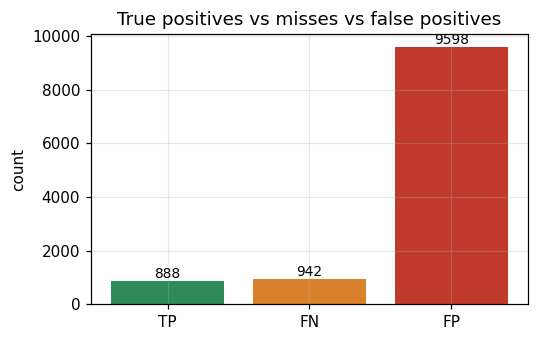

In [2]:
o = overall
print(f"sequences scored : {o['n_sequences']}")
print(f"GT pedestrians   : {o['n_gt']}")
print(f"predictions      : {o['n_pred']}")
print(f"recall           : {o['recall']:.3f}   (TP={o['tp']}  FN={o['fn']})")
print(f"precision        : {o['precision']:.3f}   (FP={o['fp']})")
if report.get("failures"):
    print(f"\nskipped sequences: {len(report['failures'])}")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["TP", "FN", "FP"], [o["tp"], o["fn"], o["fp"]],
       color=["#2e8b57", "#d9822b", "#c0392b"])
ax.set_title("True positives vs misses vs false positives")
ax.set_ylabel("count")
for i, v in enumerate([o["tp"], o["fn"], o["fp"]]):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 2. Recall by range and by point sparsity

The two breakdowns the architecture decision hinges on. Watch for the fall-off at
long range and on sparse (few-return) pedestrians.

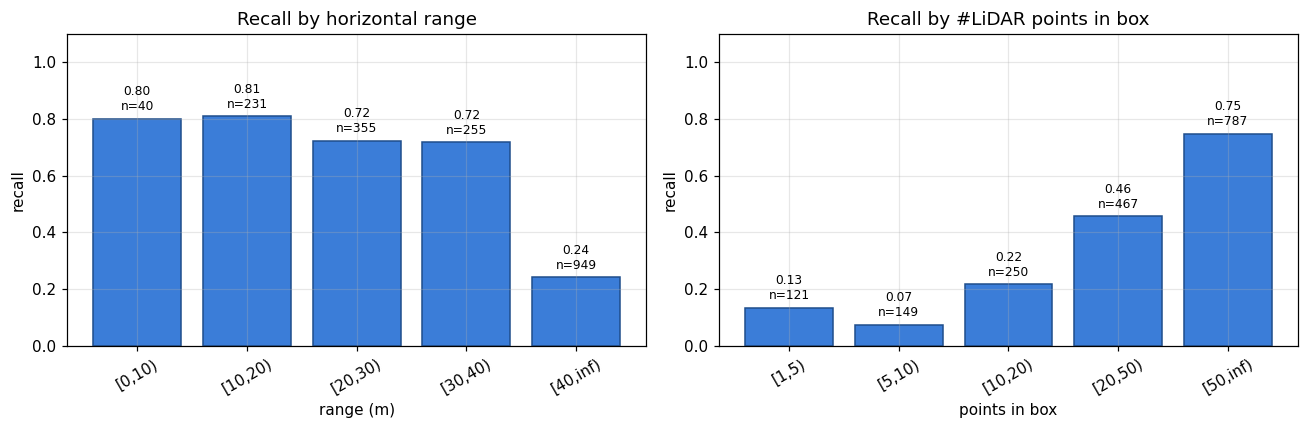

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_recall(axes[0], report["by_range_xy_m"], "Recall by horizontal range", "range (m)")
bar_recall(axes[1], report["by_lidar_points"], "Recall by #LiDAR points in box", "points in box")
plt.tight_layout(); plt.show()

## 3. Recall by occlusion

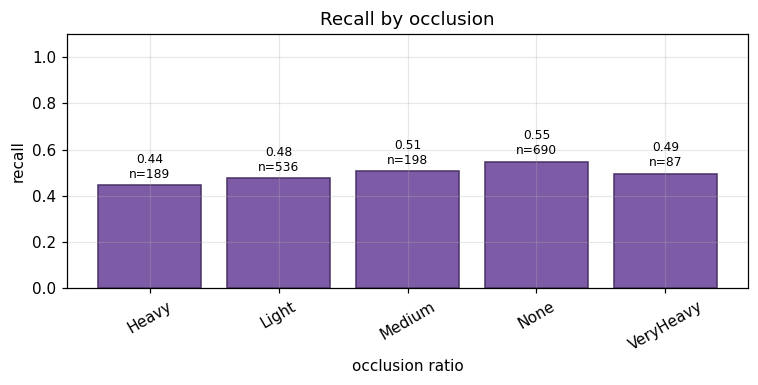

In [4]:
occ = report.get("by_occlusion", {})
if occ:
    labels = list(occ.keys())
    recall = [occ[k]["recall"] if occ[k]["recall"] is not None else 0.0 for k in labels]
    ns = [occ[k]["n_gt"] for k in labels]
    fig, ax = plt.subplots(figsize=(7, 3.6))
    bars = ax.bar(labels, recall, color="#7d5ba6", edgecolor="#4a3266")
    for bar, r, n in zip(bars, recall, ns):
        ax.text(bar.get_x() + bar.get_width() / 2, r + 0.02, f"{r:.2f}\nn={n}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.1); ax.set_ylabel("recall"); ax.set_xlabel("occlusion ratio")
    ax.set_title("Recall by occlusion"); ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()
else:
    print("no occlusion breakdown in report")

## 4. Per-sequence recall distribution

How uniform is performance across sequences? A long left tail means some scenes are
much harder than the headline number suggests.

sequences with >=1 GT: 329
median recall: 0.500 | mean: 0.444
sequences at recall 0.0: 104 | at recall 1.0: 67


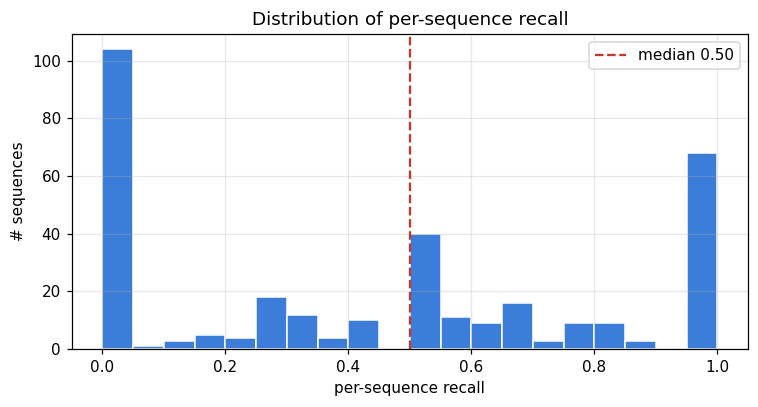

In [5]:
per_seq = [s["recall"] for s in report["per_sequence"] if s["recall"] is not None]
per_seq = np.array(per_seq)
print(f"sequences with >=1 GT: {len(per_seq)}")
print(f"median recall: {np.median(per_seq):.3f} | mean: {per_seq.mean():.3f}")
print(f"sequences at recall 0.0: {(per_seq == 0).sum()} "
      f"| at recall 1.0: {(per_seq == 1).sum()}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(per_seq, bins=np.linspace(0, 1, 21), color="#3b7dd8", edgecolor="white")
ax.axvline(np.median(per_seq), color="#c0392b", ls="--",
           label=f"median {np.median(per_seq):.2f}")
ax.set_xlabel("per-sequence recall"); ax.set_ylabel("# sequences")
ax.set_title("Distribution of per-sequence recall"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Skipped sequences

Sequences dropped during the run (e.g. no LiDAR within the keyframe gap, or a load
error) — worth a glance to confirm the skips are benign, not a systematic bug.

In [6]:
for f in report.get("failures", []):
    print(f"{f['seq_id']}: {f['reason']}")
if not report.get("failures"):
    print("no skipped sequences")

000035: no LiDAR within 0.055s (gap=0.055)
000234: no LiDAR within 0.055s (gap=0.055)
000242: no LiDAR within 0.055s (gap=0.055)
000521: no LiDAR within 0.055s (gap=0.055)
000530: no LiDAR within 0.055s (gap=0.056)
000962: no LiDAR within 0.055s (gap=0.055)


## 6. Inspect failure cases (BEV)

The breakdowns above say *where* recall drops; this section shows *why* on individual
scenes. We re-run the detector on a few sequences and draw a bird's-eye view of the
keyframe scan. Each panel **auto-zooms onto the GT pedestrians** (they can sit anywhere
from 5 m to 90 m, so a fixed window would push them off-frame), and because a 0.7 m
box is sub-pixel at LiDAR scale, every object also gets a **center marker**:

* gray dots &mdash; LiDAR points
* **green box + green &times;** &mdash; GT pedestrian the detector recovered (TP)
* **red box + red &times;** &mdash; GT pedestrian MISSED (FN), labelled `r=`range, `n=`points
* **blue dashed + blue +** &mdash; predicted pedestrian boxes (incl. false positives)
* black triangle &mdash; ego (only drawn if inside the zoom window)

Selection prefers low-recall scenes that contain a *nearby* (<25 m) pedestrian — the
diagnostically interesting failures, not the 50–90 m physics-bound losses.

> Requires the detector env (torch + OpenPCDet + the checkpoint). The cfg/ckpt paths
> are read from the report. If unavailable, this section is skipped and the report
> plots above still stand.

In [7]:
# --- Build the detector once (heavy: loads the model to GPU). ---
import os, sys

OPENPCDET_TOOLS = Path.home() / "OpenPCDet" / "tools"
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

DETECTOR = None
try:
    _cwd = Path.cwd()
    os.chdir(OPENPCDET_TOOLS)  # so the model cfg's relative _BASE_CONFIG_ resolves
    from eval_detector_recall import make_pointpillars, match_greedy
    DETECTOR = make_pointpillars(Path(cfg["pp_cfg"]), Path(cfg["pp_ckpt"]),
                                 score_thresh=cfg.get("score_thresh", 0.1))
    print("detector ready")
except Exception as e:
    print("detector unavailable -> skipping BEV section:", repr(e)[:160])
finally:
    os.chdir(_cwd)

detector ready


/home/user20/miniforge3/envs/zod-iac/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


visualizing: ['000306', '000351', '001020', '001087', '001113', '001357']


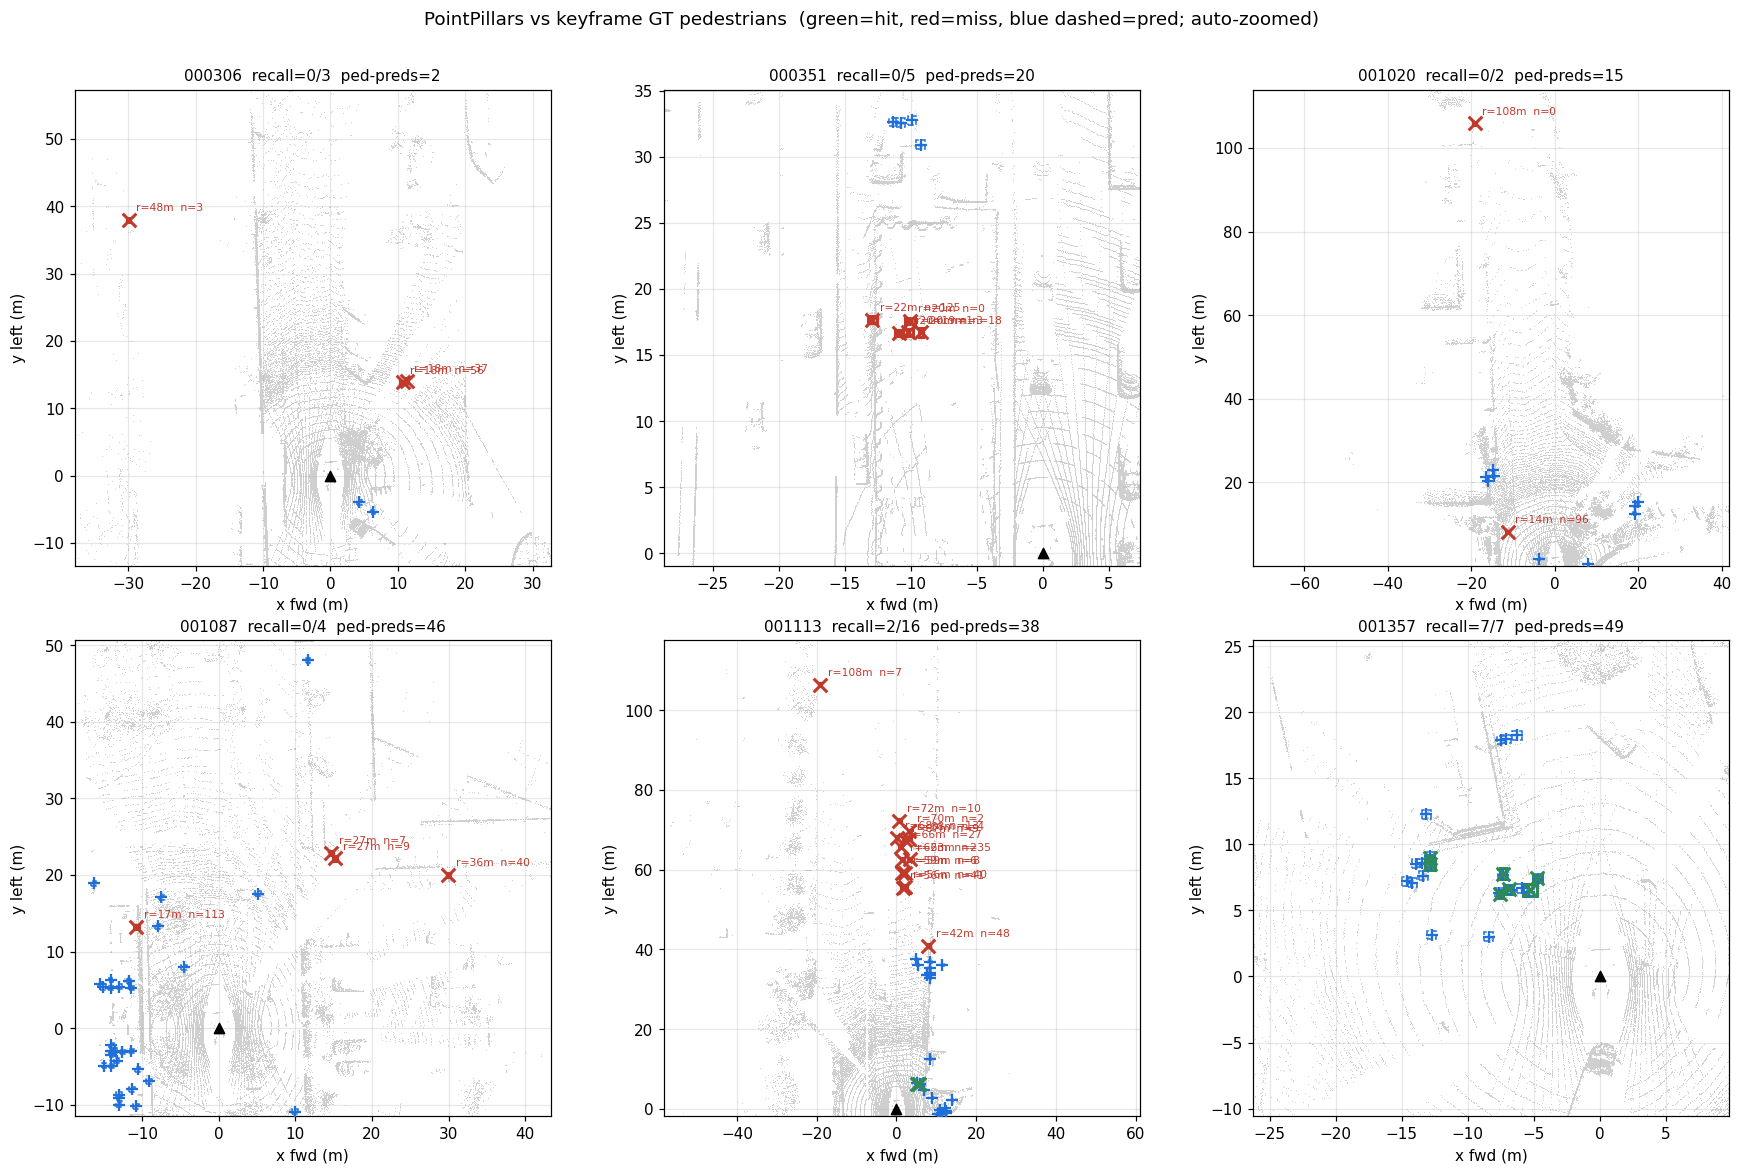

In [8]:
from matplotlib.patches import Rectangle
from dataset.keyframe import (MAX_LIDAR_GAP_S, load_keyframe_pedestrians, load_xyzi,
                              nearest_lidar_scan, parse_zod_ts, points_in_box)

SEQ_DIR = ROOT / "data" / "raw" / "sequences"

def _box(ax, c, s, color, ls="-", lw=1.5):
    ax.add_patch(Rectangle((c[0] - s[0] / 2, c[1] - s[1] / 2), s[0], s[1],
                           fill=False, edgecolor=color, linestyle=ls, linewidth=lw))

def plot_seq(ax, seq_id, match_dist=None, margin=8.0, min_half=18.0):
    """BEV of one sequence's keyframe scan, auto-zoomed onto the GT pedestrians."""
    match_dist = match_dist or cfg["match_dist_m"]
    seq_dir = SEQ_DIR / seq_id
    kts = parse_zod_ts(json.loads((seq_dir / "info.json").read_text())["keyframe_time"])
    scan, gap = nearest_lidar_scan(seq_dir / "lidar_velodyne", kts)
    if scan is None or gap > MAX_LIDAR_GAP_S:
        ax.set_title(f"{seq_id}: no LiDAR @ keyframe"); ax.axis("off"); return
    pts = load_xyzi(scan)
    gts = load_keyframe_pedestrians(seq_dir)
    preds = DETECTOR(pts, gts)
    matched = match_greedy(preds, gts, match_dist)

    # View centered on the GT pedestrians (fall back to preds, then ego).
    focus = [g.center[:2] for g in gts] or [d.center[:2] for d in preds] or [np.zeros(2)]
    C = np.asarray(focus, dtype=float)
    cx, cy = C[:, 0].mean(), C[:, 1].mean()
    half = max(min_half, float(np.abs(C - [cx, cy]).max()) + margin)

    m = (np.abs(pts[:, 0] - cx) <= half) & (np.abs(pts[:, 1] - cy) <= half)
    p = pts[m]
    if len(p) > 60000:
        p = p[::3]
    ax.scatter(p[:, 0], p[:, 1], s=0.4, c="#cfcfcf", linewidths=0)
    for box, hit in zip(gts, matched):
        col = "#2e8b57" if hit else "#c0392b"
        _box(ax, box.center, box.size, col, lw=2.0)
        ax.scatter(box.center[0], box.center[1], marker="x", c=col, s=80,
                   linewidths=2.0, zorder=6)
        if not hit:
            ax.annotate(f"r={box.range_xy:.0f}m  n={points_in_box(pts, box)}",
                        (box.center[0], box.center[1]), textcoords="offset points",
                        xytext=(5, 6), color="#c0392b", fontsize=7)
    for d in preds:
        _box(ax, d.center, d.size, "#1f6fdb", ls="--", lw=1.0)
        ax.scatter(d.center[0], d.center[1], marker="+", c="#1f6fdb", s=55, zorder=5)
    if abs(cx) <= half and abs(cy) <= half:
        ax.scatter([0], [0], marker="^", c="black", s=45, zorder=5)
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
    ax.set_aspect("equal"); ax.set_xlabel("x fwd (m)"); ax.set_ylabel("y left (m)")
    ax.set_title(f"{seq_id}  recall={sum(matched)}/{len(gts)}  ped-preds={len(preds)}",
                 fontsize=10)

def _nearest_gt_range(seq_id):
    gts = load_keyframe_pedestrians(SEQ_DIR / seq_id)
    return min((g.range_xy for g in gts), default=np.inf)

if DETECTOR is not None:
    scored = sorted([s for s in report["per_sequence"]
                     if s.get("recall") is not None and s["n_gt"] >= 2],
                    key=lambda s: s["recall"])
    # low-recall scenes WITH a nearby pedestrian (diagnostic, not a 50-90m physics-loss)
    bad = [s["seq_id"] for s in scored
           if s["recall"] < 1.0 and _nearest_gt_range(s["seq_id"]) < 25.0][:5]
    good = next((s["seq_id"] for s in reversed(scored)
                 if s["recall"] == 1.0 and _nearest_gt_range(s["seq_id"]) < 25.0), None)
    seqs = bad + ([good] if good else [])
    # seqs = ["000007"]   # <- uncomment/edit to inspect specific sequence ids
    print("visualizing:", seqs)
    cols = 3; rows = (len(seqs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.4 * cols, 5.4 * rows), squeeze=False)
    for i, sq in enumerate(seqs):
        plot_seq(axes[i // cols][i % cols], sq)
    for j in range(len(seqs), rows * cols):
        axes[j // cols][j % cols].axis("off")
    fig.suptitle("PointPillars vs keyframe GT pedestrians  "
                 "(green=hit, red=miss, blue dashed=pred; auto-zoomed)", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

**Reading the plots** (note each panel is auto-zoomed — check the axis scale):

* a **red &times;** far from ego with small `n=` is an expected, physics-bound miss;
* a **red &times; that is close with many points** is a real domain-gap failure that
  fine-tuning should fix;
* a **red &times; with a blue + sitting right on it** means the detection existed but
  fell outside the 2 m match distance (or was greedily claimed by an adjacent GT) — a
  localization / matching issue, not a detection one;
* lots of stray **blue +** away from any GT is the false-positive load the KF/RTS
  linker must reject downstream.

To inspect specific scenes, set the `seqs` list in the cell above.